# QQQ (Invesco QQQ Trust)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from scipy.stats import shapiro, kstest
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

%matplotlib inline

C:\Users\niush\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Path to the qqq data file
file_path = "qqq.us.txt"

# Load the file
df = pd.read_csv(file_path, delimiter=',')

In [3]:
file_path = "QQQ_categorized_data.csv"

categorized_df = pd.read_csv(file_path, delimiter=',')

#### Descriptive statistics

In [4]:
df.describe()

,Open,High,Low,Close,Volume,OpenInt
count,4701.000000,4701.000000,4701.000000,4701.000000,4.701000e+03,4701.0
mean,58.398648,58.888507,57.837278,58.386467,8.054378e+07,0.0
std,31.211635,31.316778,31.071677,31.220362,5.903922e+07,0.0
min,17.830000,18.361000,17.665000,17.938000,5.828392e+06,0.0
25%,34.904000,35.173000,34.559000,34.876000,3.447708e+07,0.0
50%,45.743000,46.112000,45.279000,45.656000,7.083852e+07,0.0
75%,79.321000,80.286000,78.248000,79.160000,1.074447e+08,0.0
max,153.810000,154.540000,153.620000,154.510000,6.755370e+08,0.0


In [5]:
categorized_df.describe()

,Open,High,Low,Close,Volume
count,4231.000000,4231.000000,4231.000000,4231.000000,4.231000e+03
mean,57.027859,57.515297,56.466528,57.014087,7.482830e+07
std,29.853908,29.984956,29.669958,29.853178,4.156988e+07
min,17.830000,18.361000,17.665000,17.938000,1.743161e+07
25%,34.710500,34.999000,34.393500,34.646500,3.710127e+07
50%,45.524000,45.799000,44.988000,45.439000,7.083852e+07
75%,73.754000,74.455000,72.672000,73.459500,1.035248e+08
max,153.670000,154.082000,153.340000,153.870000,1.859483e+08


#### Skewness and elongation analysis

In [6]:
# We are only calculating the “Skewness” and “Kurtosis” for “Volume” as before and after
# cause that’s the only column that we have changed 

print("Volume before:")
print(f"Volume Skewness: {skew(df['Volume'])}")    
print(f"Volume Kurtosis: {kurtosis(df['Volume'])}")

Volume before:
Volume Skewness: 1.9492465519557864
Volume Kurtosis: 7.694672073296985


In [7]:
print("Dataset after:\n")

columns_to_check = ['Open', 'Close', 'High', 'Low', 'Volume']

for column in columns_to_check:
    print(f"{column} Skewness: {skew(categorized_df[column])}")
    print(f"{column} Kurtosis: {kurtosis(categorized_df[column])}\n")

Dataset after:

Open Skewness: 1.1256183599511647
Open Kurtosis: 0.4808508721037277

Close Skewness: 1.1271508204606153
Close Kurtosis: 0.4862149064572474

High Skewness: 1.1165592362277394
High Kurtosis: 0.44501427677212435

Low Skewness: 1.1377438490202647
Low Kurtosis: 0.5265421533209138

Volume Skewness: 0.5344396500948225
Volume Kurtosis: -0.5938077940737734



#### Statistical hypothesis testing

In [8]:
# To check whether the data follows a normal distribution (Shapiro-Wilk), (nKolmogorov)
stat, p = shapiro(categorized_df['Close'])
print(f"Shapiro-Wilk Test: \nStatistic = {stat} \np-value = {p}")

stat, p = kstest(categorized_df['Close'], 'norm')
print(f"\nKolmogorov-Smirnov Test: \nStatistic = {stat} \np-value = {p}")


# Checking if the average of two columns is different (T-test)
t_stat, p_val = ttest_ind(categorized_df['Open'], categorized_df['Close'])
print(f"\nT-Test: \nStatistic = {t_stat} \np-value = {p_val}")


# Checking the mean difference between multiple columns (Anova)
f_stat, p_val = f_oneway(categorized_df['Open'], categorized_df['Close'], categorized_df['High'])
print(f"\nANOVA Test: \nStatistic = {f_stat} \np-value = {p_val}")


# Checking the independence or relationship between two categorical columns (Chi-Square)
contingency_table = pd.crosstab(categorized_df['High_category'], categorized_df['Volume_category'])
chi2, p_val, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi-Square Test: \nStatistic = {chi2} \np-value = {p_val}")

Shapiro-Wilk Test: 
Statistic = 0.8742127790815702 
p-value = 4.616998488661642e-50

Kolmogorov-Smirnov Test: 
Statistic = 1.0 
p-value = 0.0

T-Test: 
Statistic = 0.021218764138862808 
p-value = 0.9830716464379672

ANOVA Test: 
Statistic = 0.38577228766123345 
p-value = 0.6799333089002184

Chi-Square Test: 
Statistic = 7386.284694873749 
p-value = 2.8686474773490836e-170


#### Correlation Analysis

Calculating Pearson and Spearman correlation coefficients

In [9]:
# Pearson correlation
pearson_corr, p_val = pearsonr(categorized_df['Low'], categorized_df['Volume'])
print(f"Pearson Correlation: \nCorrelation = {pearson_corr} \np-value = {p_val}")

# Spearman correlation
spearman_corr, p_val = spearmanr(categorized_df['Low'], categorized_df['Volume'])
print(f"\nSpearman Correlation: \nCorrelation = {spearman_corr} \np-value = {p_val}")


Pearson Correlation: 
Correlation = -0.654195381872901 
p-value = 0.0

Spearman Correlation: 
Correlation = -0.7313445158375778 
p-value = 0.0


In [10]:
# Calculating the correlation matrix
correlation_matrix = categorized_df[['Open', 'Low', 'High', 'Close', 'Volume']].corr(method='pearson')
correlation_matrix

,Open,Low,High,Close,Volume
Open,1.000000,0.999680,0.999783,0.999564,-0.653198
Low,0.999680,1.000000,0.999449,0.999698,-0.654195
High,0.999783,0.999449,1.000000,0.999729,-0.652938
Close,0.999564,0.999698,0.999729,1.000000,-0.653600
Volume,-0.653198,-0.654195,-0.652938,-0.653600,1.000000


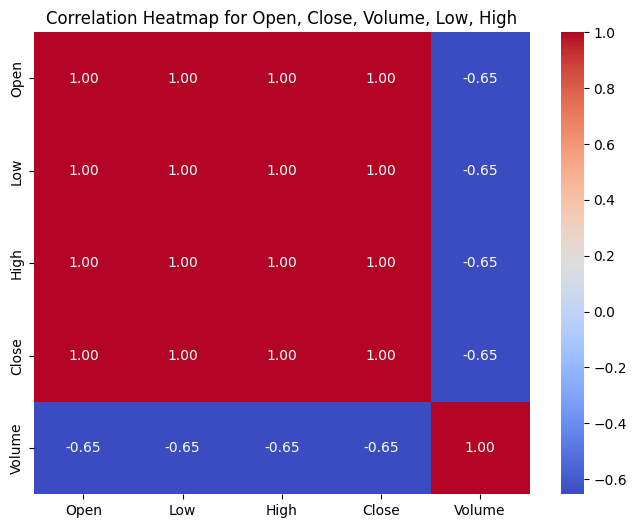

In [11]:
# drawing for heatmap matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap for Open, Close, Volume, Low, High")
plt.show()


In [12]:
# extracting strong correlations
strong_correlations = correlation_matrix[(correlation_matrix > 0.7) | (correlation_matrix < -0.7)]
print("Strong Correlations:")
print(strong_correlations)


Strong Correlations:
            Open       Low      High     Close  Volume
Open    1.000000  0.999680  0.999783  0.999564     NaN
Low     0.999680  1.000000  0.999449  0.999698     NaN
High    0.999783  0.999449  1.000000  0.999729     NaN
Close   0.999564  0.999698  0.999729  1.000000     NaN
Volume       NaN       NaN       NaN       NaN     1.0


#### Dispersion Analysis

In [13]:
dispersion = categorized_df['Volume'].var() / categorized_df['Volume'].mean()
print(f"Dispersion Ratio: {dispersion}")


Dispersion Ratio: 23093602.438221455


#### Multicollinearity Analysis

In [14]:
X = categorized_df[['Open', 'High', 'Low', 'Close', 'Volume']]
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)


  feature           VIF
0    Open  27899.506867
1    High  30040.447420
2     Low  19829.722283
3   Close  23667.986962
4  Volume      1.729674


#### Comparative Analysis

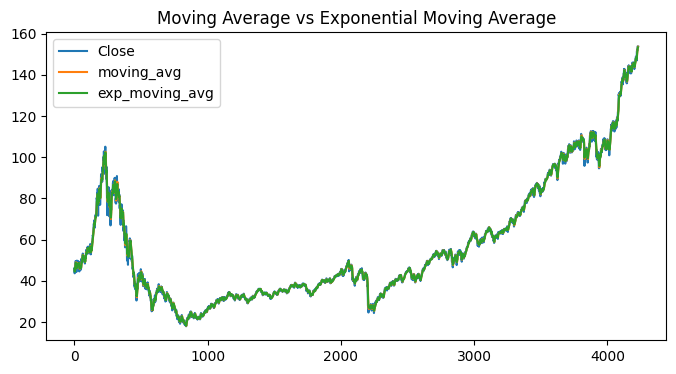

In [15]:
categorized_df['moving_avg'] = categorized_df['Close'].rolling(window=5).mean()
categorized_df['exp_moving_avg'] = categorized_df['Close'].ewm(span=5).mean()

categorized_df[['Close', 'moving_avg', 'exp_moving_avg']].plot(figsize=(8, 4))
plt.title("Moving Average vs Exponential Moving Average")
plt.show()


#### Statistical Regression Analysis

In [16]:
X = categorized_df[['Open', 'High', 'Low']]
y = categorized_df['Close']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Close   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 7.186e+06
Date:                Sat, 23 Nov 2024   Prob (F-statistic):               0.00
Time:                        05:52:57   Log-Likelihood:                -2312.1
No. Observations:                4231   AIC:                             4632.
Df Residuals:                    4227   BIC:                             4658.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0708      0.014     -4.994      0.0

#### Drawing a scatter plot with a regression line

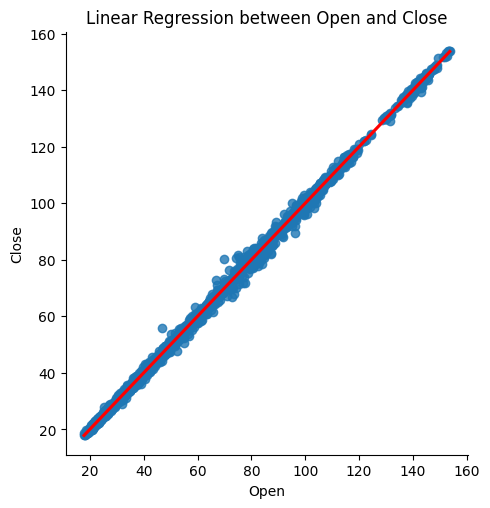

In [17]:
sns.lmplot(x='Open', y='Close', data=categorized_df, line_kws={'color': 'red'})
plt.title("Linear Regression between Open and Close")
plt.show()
